In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df=pd.read_csv('final_dataset.csv')

In [43]:
df.sample(3)

,Unnamed: 0,event_name,season,match_number,date,city,venue,team1,team2,toss_winner,...,umpire2,tv_umpire,reserve_umpire,match_type,overs_limit,balls_per_over,gender,team_type,team1_players,team2_players
694,694,Indian Premier League,2018,59.0,2018-05-25,Kolkata,Eden Gardens,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,...,Nitin Menon,AK Chaudhary,A Nand Kishore,T20,20,6,male,club,"WP Saha, S Dhawan, KS Williamson, Shakib Al Ha...","CA Lynn, SP Narine, N Rana, RV Uthappa, KD Kar..."
27,27,Indian Premier League,2007/08,28.0,2008-05-08,Delhi,Arun Jaitley Stadium,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,...,RB Tiffin,K Hariharan,Unknown,T20,20,6,male,club,"G Gambhir, V Sehwag, AB de Villiers, S Dhawan,...","S Vidyut, SP Fleming, MS Dhoni, SK Raina, JA M..."
740,740,Indian Premier League,2019,45.0,2019-04-27,Jaipur,Sawai Mansingh Stadium,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,YC Barde,S Ravi,K Srinivasan,T20,20,6,male,club,"DA Warner, KS Williamson, MK Pandey, V Shankar...","AM Rahane, LS Livingstone, SV Samson, SPD Smit..."


### Univariate Analysis

#### Task 1: Identify the most successful franchises overall.

In [44]:
result=df.winner.value_counts().reset_index()
result

,winner,count
0,Mumbai Indians,155
1,Chennai Super Kings,148
2,Royal Challengers Bengaluru,143
3,Kolkata Knight Riders,140
4,Punjab Kings,126
5,Delhi Capitals,125
6,Rajasthan Royals,123
7,Sunrisers Hyderabad,102
8,Gujarat Titans,47
9,Lucknow Super Giants,34


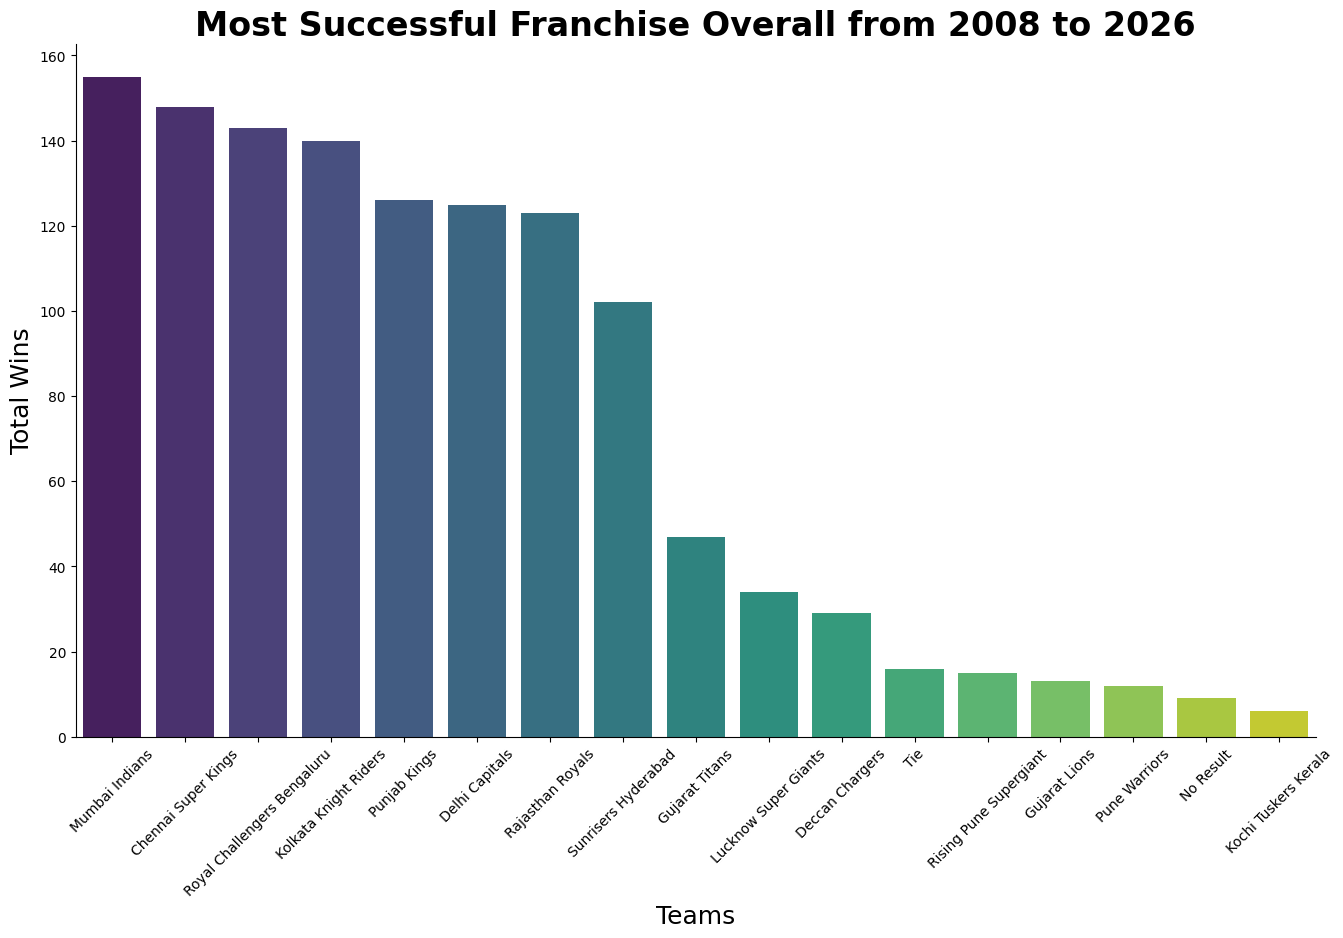

In [45]:
plt.subplots(figsize=(16,9))
sns.barplot( data=result, x='winner' , y='count' , palette='viridis',hue='winner' )
plt.title("Most Successful Franchise Overall from 2008 to 2026",fontsize=24,fontweight='bold')
plt.xlabel("Teams",fontsize=18)
plt.ylabel("Total Wins",fontsize=18)
plt.xticks(rotation = 45)

sns.despine()

#### Task 2: Find the most valuable players.

In [46]:
df['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
V Kohli           22
RG Sharma         21
SP Narine         18
DA Warner         18
MS Dhoni          18
RA Jadeja         17
KL Rahul          17
SR Watson         16
Name: count, dtype: int64

#### Task 3: Analyze the preferred toss decision.

In [47]:
df['toss_decision'].value_counts()*100/df.shape[0] # Field is more preferred

toss_decision
field    66.371681
bat      33.628319
Name: count, dtype: float64

### Bivariate Analysis

#### Task 4: The Toss Advantage. Does winning the toss actually translate to winning the match?

In [48]:
round(df[df['winner']==df['toss_winner']].shape[0]*100/df.shape[0],2)  # Not likely but it does give you an very little advantage 

50.52

#### Task 5: Defending vs. Chasing. Is it easier to win by setting a target or chasing one?

In [49]:
decisive_matches = df[~df['result_type'].isin(['tie','no result'])]

defending =decisive_matches[decisive_matches['win_by_runs'] > 0].shape[0] * 100 / decisive_matches.shape[0]
chasing = decisive_matches[decisive_matches['win_by_wickets'] > 0].shape[0] * 100 / decisive_matches.shape[0]

print(f"Defending Win Rate: {round(defending,2)}%")
print(f"Chasing Win Rate: {round(chasing,2)}%")

# So, According to the Analysis Chasing a target gives an advantage

Defending Win Rate: 45.81%
Chasing Win Rate: 54.19%


#### Task 6: Toss strategy evolution over the years.

In [50]:
result=df.groupby(['season','toss_decision'])['winner'].count().unstack()

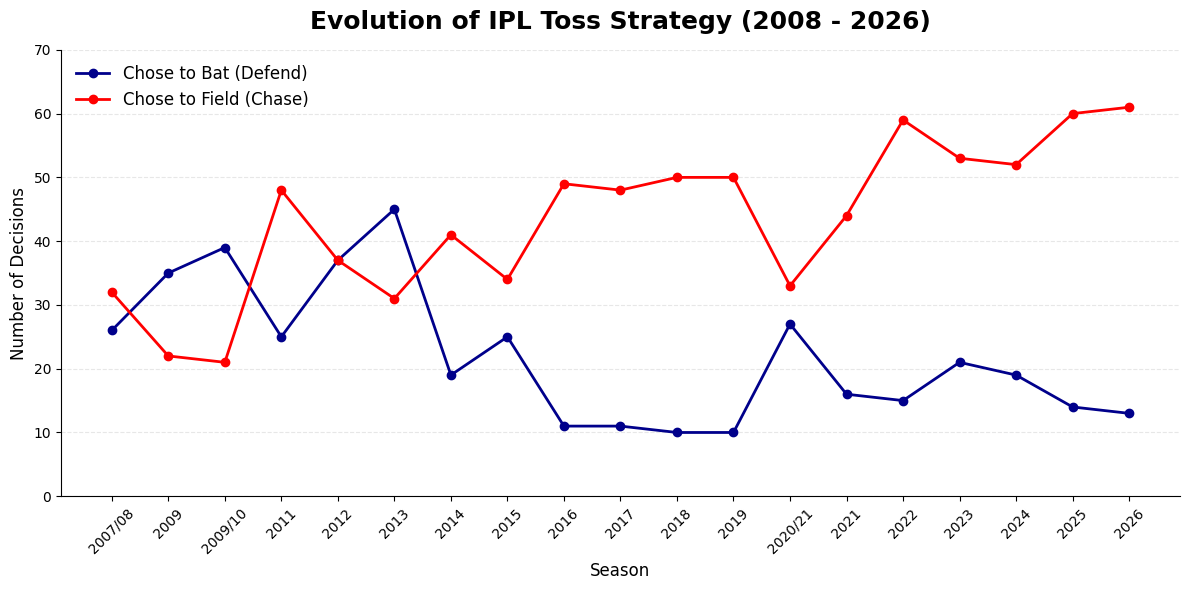

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(result.index, result['bat'], color='darkblue', marker='o', linewidth=2, label='Chose to Bat (Defend)')
ax.plot(result.index, result['field'], color='red', marker='o', linewidth=2, label='Chose to Field (Chase)')


ax.set_title("Evolution of IPL Toss Strategy (2008 - 2026)", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Season', fontsize=12, color='black')
ax.set_ylabel('Number of Decisions', fontsize=12, color='black')
ax.set_ylim(0, 70)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(result.index, rotation=45)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

#### Task 7: Venue Characteristics (Batting Paradises vs Bowling Pitches).

In [52]:
venue_counts = df['venue'].value_counts()
valid_venues = venue_counts[venue_counts >= 20].index
filtered_venues_df = df[df['venue'].isin(valid_venues)]

venue_scoring = filtered_venues_df.groupby('venue')['team1_runs'].mean().sort_values(ascending=False).reset_index()
overall_avg = filtered_venues_df['team1_runs'].mean()

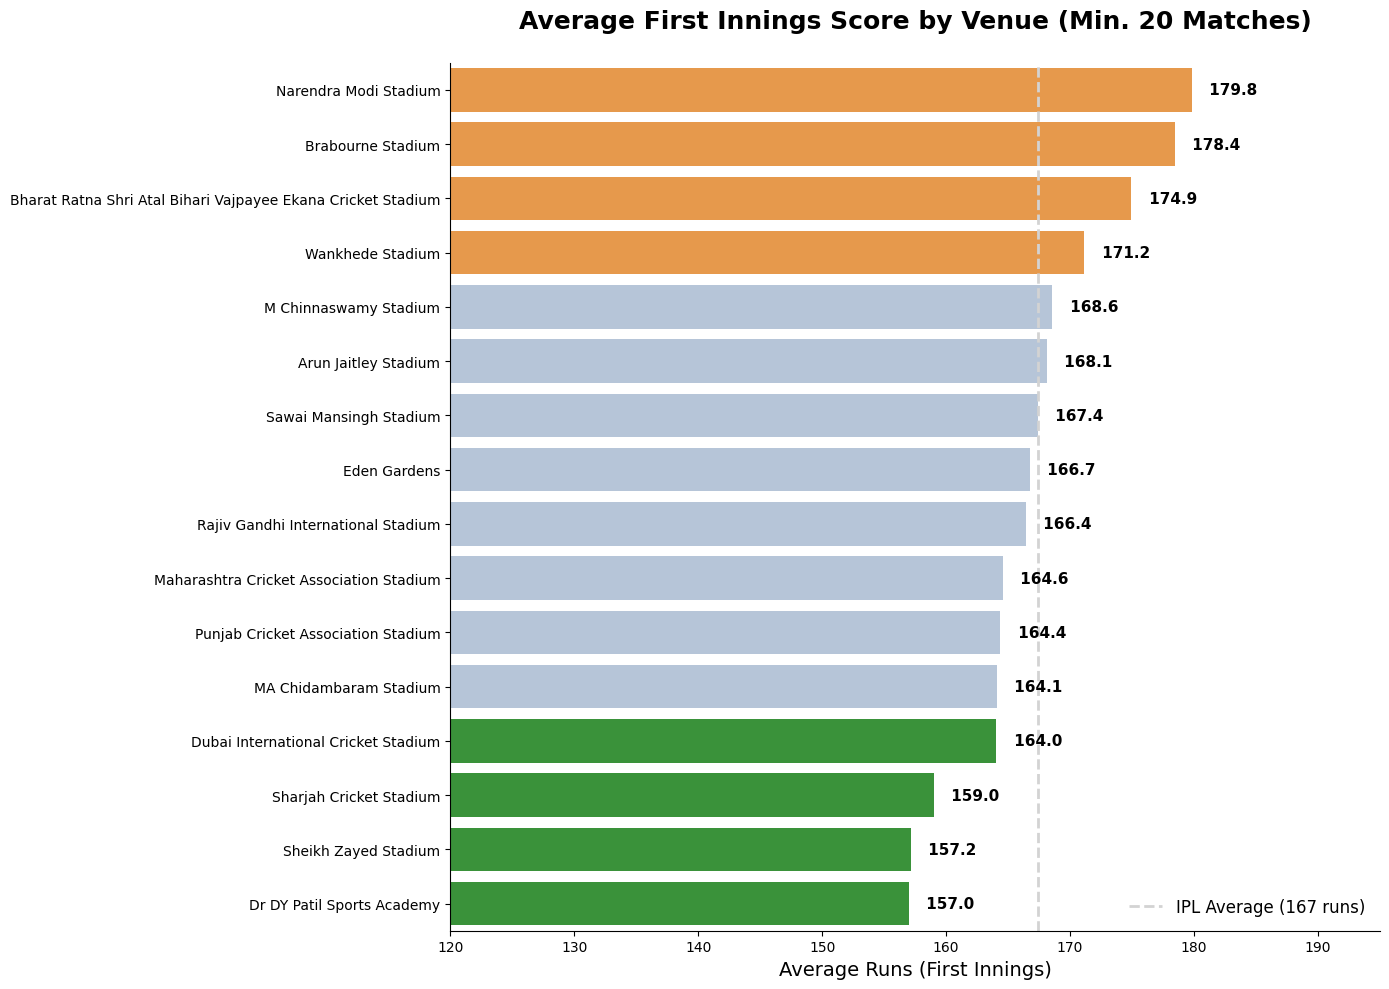

In [53]:
fig, ax = plt.subplots(figsize=(14, 10))

colors = ["#FF9933"]*4  + ['#b0c4de']*(len(venue_scoring)-8) + ['#2ca02c']*4

bars = sns.barplot(data=venue_scoring, x='team1_runs', y='venue', hue='venue',ax=ax,palette=colors,legend=False)

ax.axvline(overall_avg, color='lightgrey', linestyle='--', linewidth=2, label=f'IPL Average ({overall_avg:.0f} runs)')

for i, v in enumerate(venue_scoring['team1_runs']):
    ax.text(v + 1, i, f" {round(v,1)}", va='center', fontsize=11, fontweight='bold', color='black')

ax.set_title("Average First Innings Score by Venue (Min. 20 Matches)", fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Average Runs (First Innings)", fontsize=14)
ax.set_ylabel("")
ax.set_xlim(120, 195) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

#### Task 8: Fortress Stadiums. Which teams have the highest win percentage in their home cities?

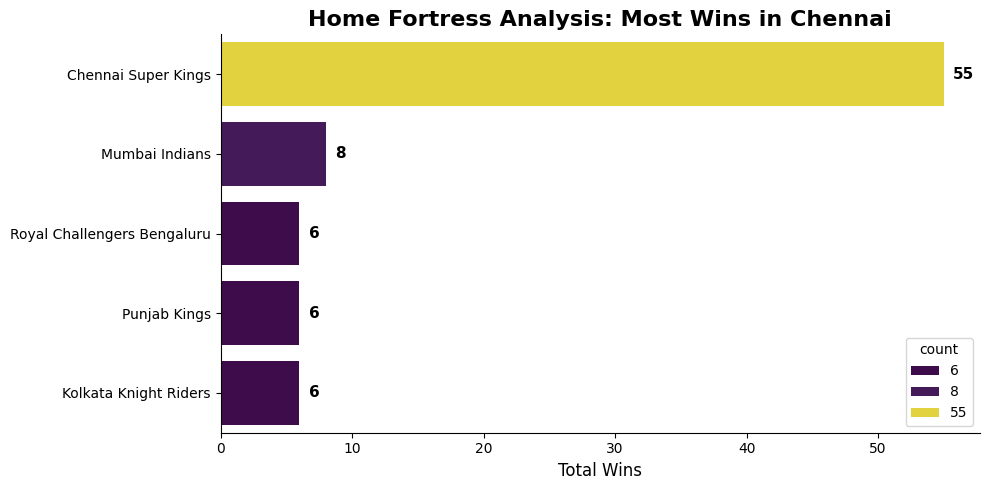

In [54]:
def analyze_fortress(city_name):
    city_matches = df[df['city'] == city_name]
    
    if city_matches.empty:
        return f"No matches found in the dataset for {city_name}."
    
    wins = city_matches['winner'].value_counts().head(5)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=wins.values, y=wins.index, palette='viridis', ax=ax,hue=wins)
    
    ax.set_title(f"Home Fortress Analysis: Most Wins in {city_name}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Total Wins", fontsize=12)
    ax.set_ylabel("")
    
    for i, v in enumerate(wins.values):
        ax.text(v + 0.7, i, str(v), va='center',fontsize=11, fontweight='bold')
        
    sns.despine()
    plt.tight_layout()
    plt.show()


analyze_fortress('Chennai')


#### Task 9: Ultimate Rivalries (Head-to-Head).

--- HEAD-TO-HEAD: Mumbai Indians vs Chennai Super Kings ---
Total Decisive Matches Played: 41

Mumbai Indians: 21 Wins (51.2%)
Chennai Super Kings: 20 Wins (48.8%)


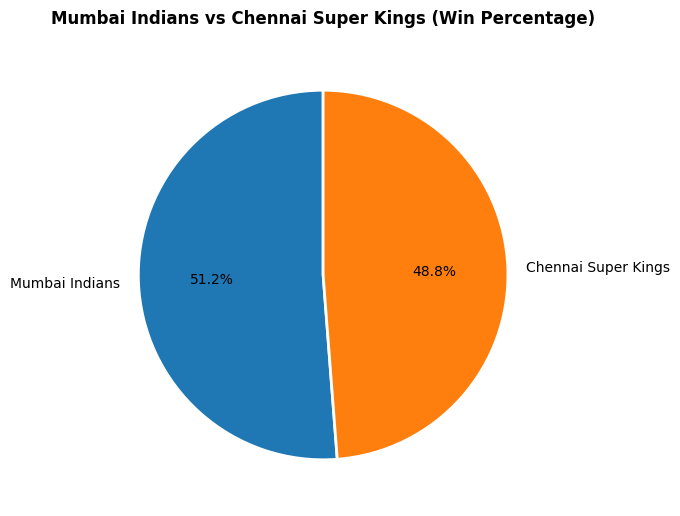

In [55]:
def analyze_rivalry(team_A, team_B):
    rivalry_df = df[((df['team1'] == team_A) & (df['team2'] == team_B)) | 
                    ((df['team1'] == team_B) & (df['team2'] == team_A))]
    
    if rivalry_df.empty:
        return f"No head-to-head matches found between {team_A} and {team_B}."
    
    wins = rivalry_df['winner'].value_counts()
    total_matches = wins.sum()
    
    print(f"--- HEAD-TO-HEAD: {team_A} vs {team_B} ---")
    print(f"Total Decisive Matches Played: {total_matches}\n")
    
    for team, count in wins.items():
        win_pct = (count / total_matches) * 100
        print(f"{team}: {count} Wins ({win_pct:.1f}%)")
        
    fig, ax = plt.subplots(figsize=(6, 6))
    
    colors = ['#1f77b4', '#ff7f0e'] 
    
    ax.pie(wins, labels=wins.index, autopct='%1.1f%%', startangle=90, 
           colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    
    ax.set_title(f"{team_A} vs {team_B} (Win Percentage)", fontweight='bold', pad=15)
    plt.show()


analyze_rivalry('Mumbai Indians', 'Chennai Super Kings')

### Conclusion

### IPL Exploratory Data Analysis (2008–2026): Key Trends and Insights

After looking closely at all the IPL match data from 2008 to 2026, several clear trends and key facts stand out:

* **The Top Teams:** **Mumbai Indians (155 wins)** and **Chennai Super Kings (148 wins)** are the clear kings of the tournament. They have won way more matches than any other team. Individually, **AB de Villiers** stands out the most with a record-breaking **25 Player of the Match awards**.

* **The Toss Doesn't Matter:** Winning the coin toss gives teams almost no extra advantage. Historically, teams that win the toss only end up winning the actual match **50.5%** of the time. 

* **Chasing is Always Better:** While winning the toss is just luck, what captains choose to do next is what matters. Teams that bowl first and chase down a target win **53%** of the time, compared to only **45%** for teams trying to defend a score. Because of this, captains have chosen to field first much more often in recent years.

* **Grounds Change the Game:** Where the match is played completely changes how many runs are scored. Grounds like the **Narendra Modi Stadium** and **Brabourne Stadium** are absolute batting paradises, where teams score around **180 runs** in the first innings. On the other hand, pitches like **Sharjah** and **Dr DY Patil Stadium** make it much harder for batsmen to score.

* **Chennai's Home Fortress:** The advantage of playing on your own ground is strongest in Chennai. The **Chennai Super Kings** have won **55 matches** at home, which is nearly seven times more than any visiting team has ever managed there.

* **The Ultimate Rivalry:** In the massive battle between MI and CSK, the **Mumbai Indians** have a tiny lead, winning **51.2%** of their **41 head-to-head matches**. This shows just how incredibly close the league's top two teams really are.
